# Experiment 0 — pilot run

Goal: **does every method run end-to-end** on every dataset? One fold, no HPO; numbers are indicative. Foundation models are highlighted in red in every chart. Figures → `figures/experiment0/` (wiped on rerun).

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, method_ranking_bars, learning_curve, imbalance_curve,
    metric_boxplots, metric_bars, compute_time_bars, compute_time_boxplot,
    rank_heatmap, rank_boxplots, hpo_improvement_bars, runtime_performance_scatter,
    pd_summary_text, lgd_summary_text,
)
from src.utils.report import notebook_report, capture, section
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment0')


In [2]:
df = load_summary(SUMMARY_DIR, experiment='experiment0', task='pd', aggregated=False)
try:
    df_lgd = load_summary(SUMMARY_DIR, experiment='experiment0', task='lgd', aggregated=False)
except FileNotFoundError:
    df_lgd = None


## Coverage — which methods produced a result on every dataset?

In [3]:
cov = df.groupby('method')['dataset'].nunique().sort_values(); n_ds = df['dataset'].nunique()


## PD — AUC

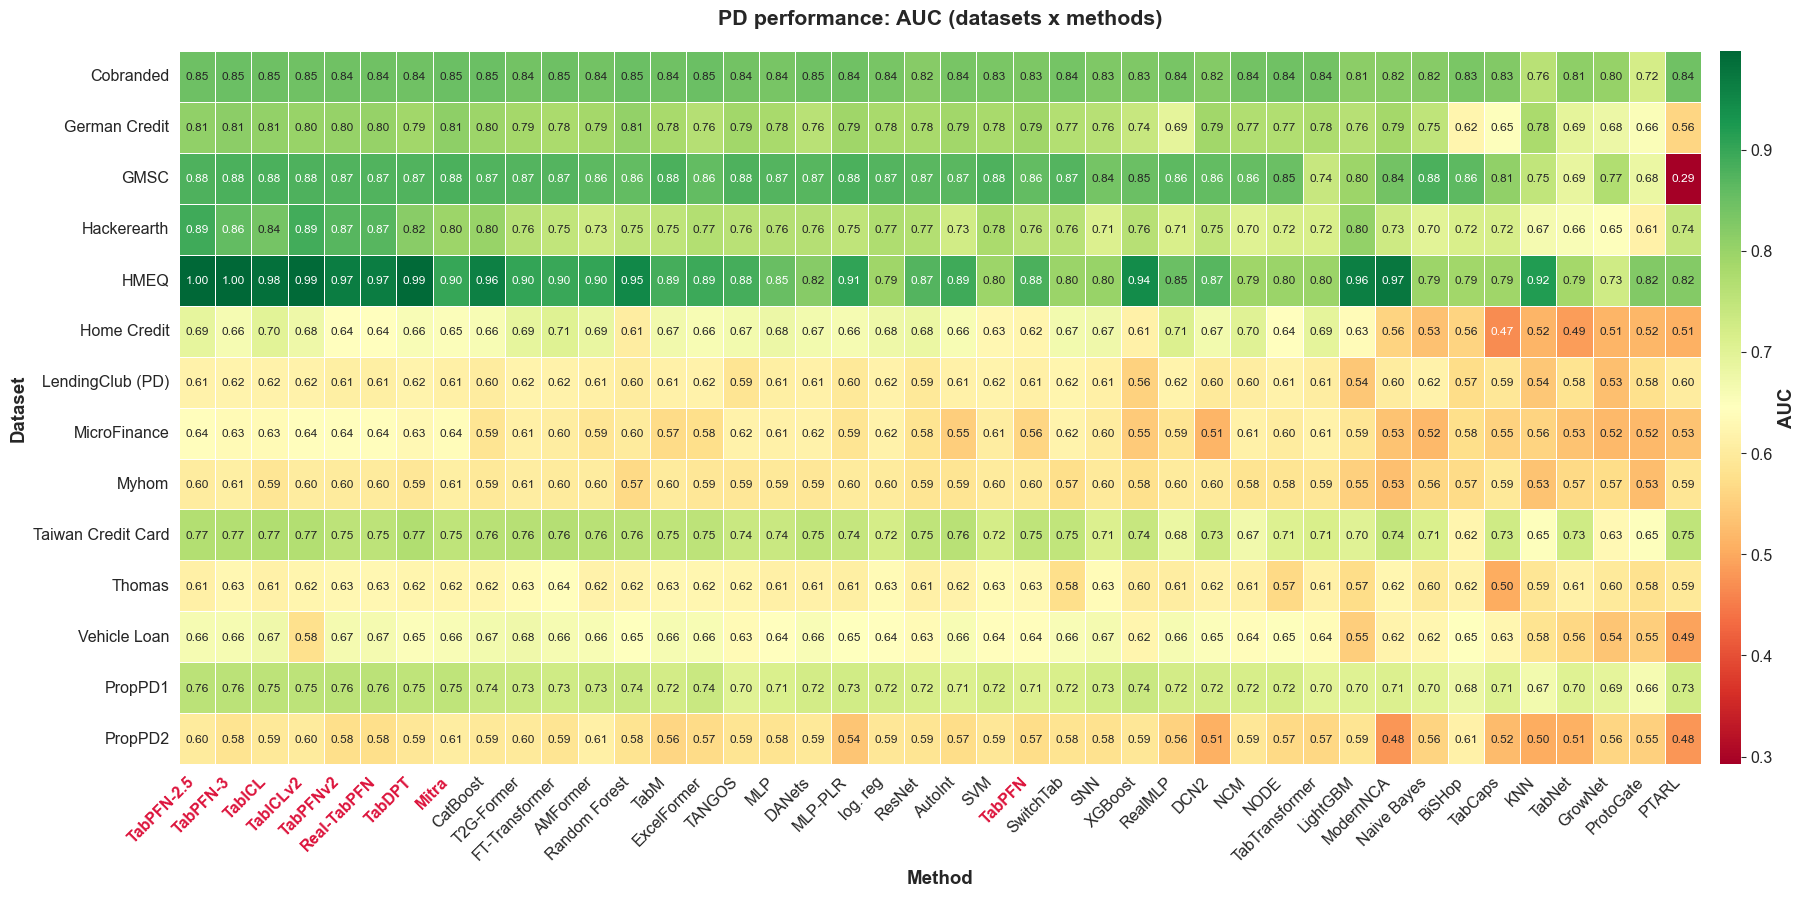

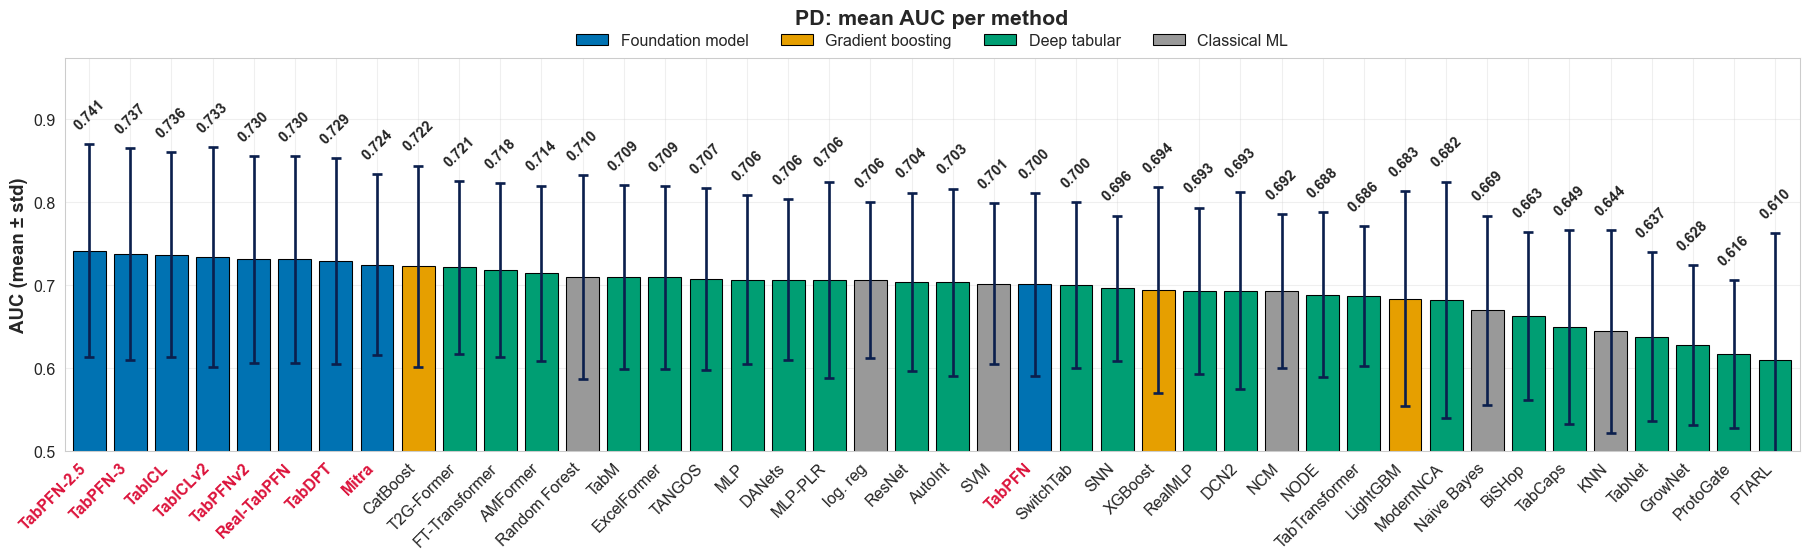

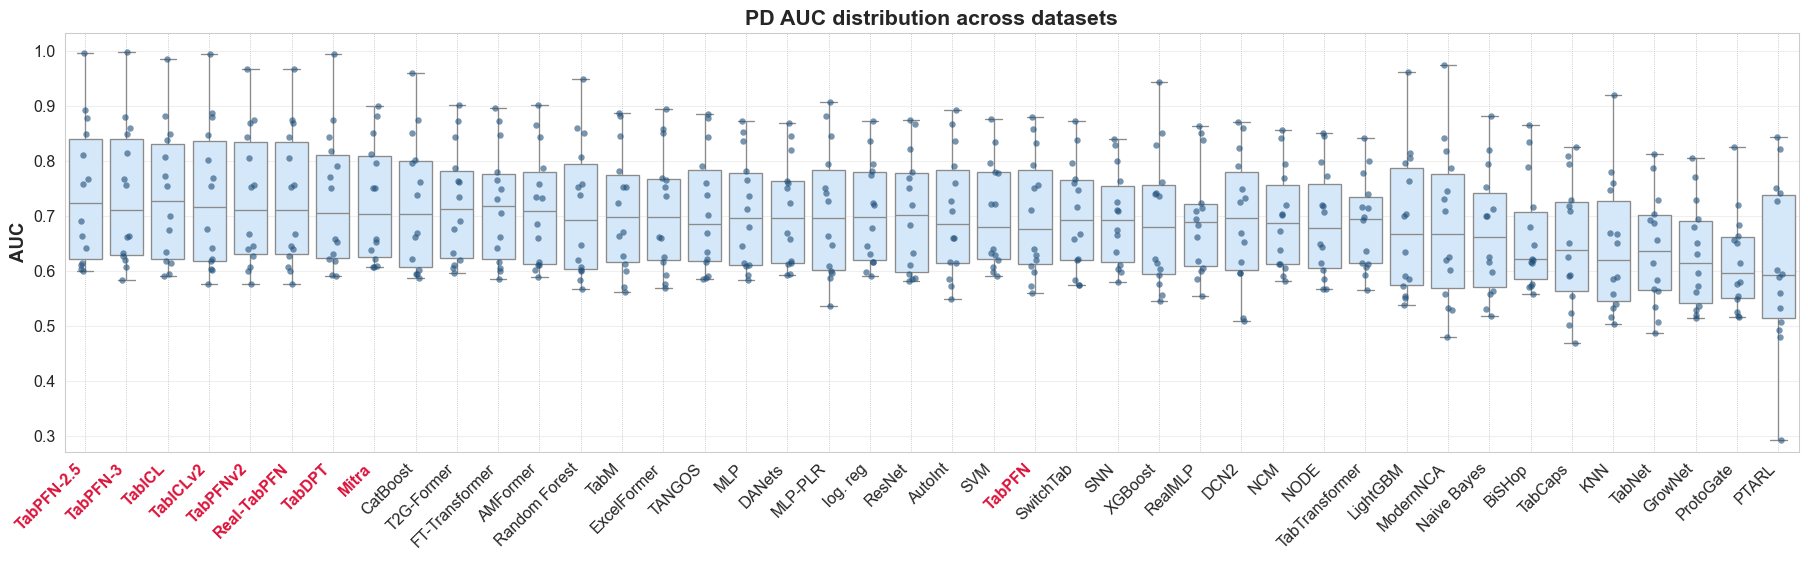

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment0/pd_box_auc.pdf')

In [4]:
performance_heatmap(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)


## PD — compute time + cost/quality

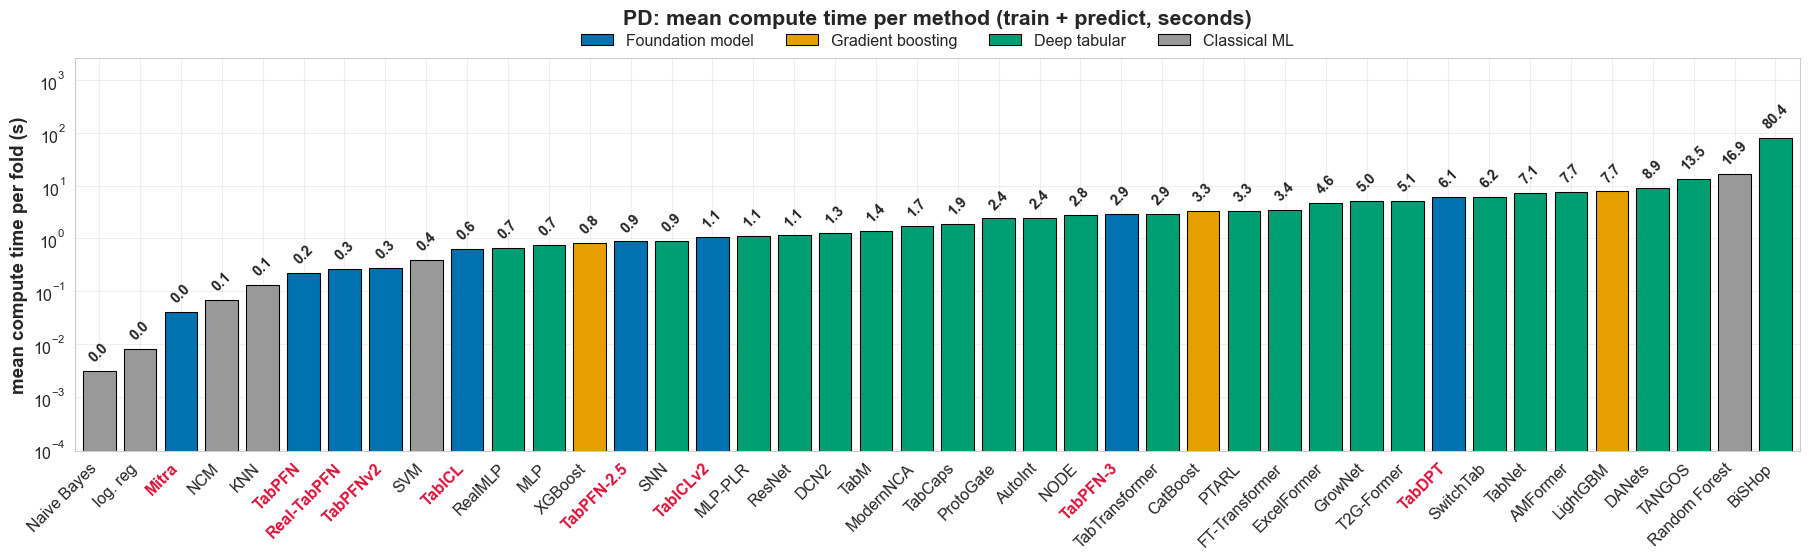

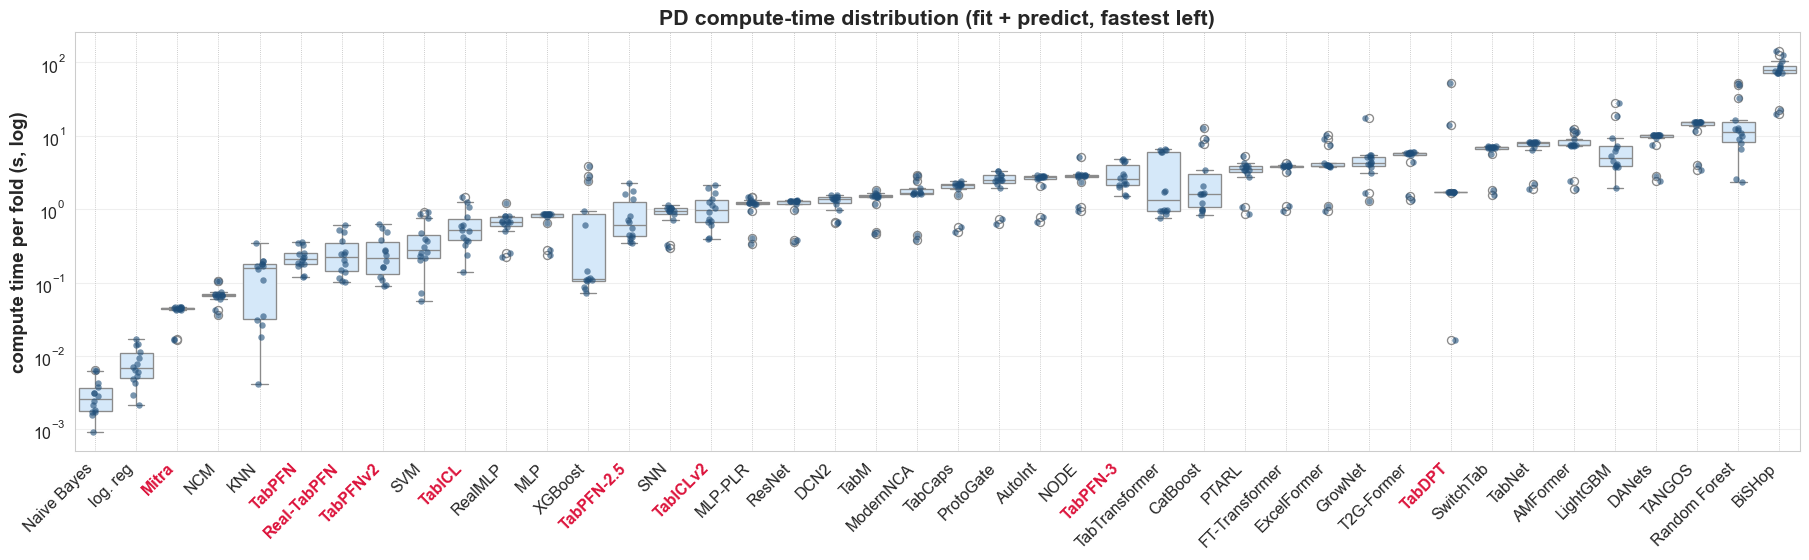

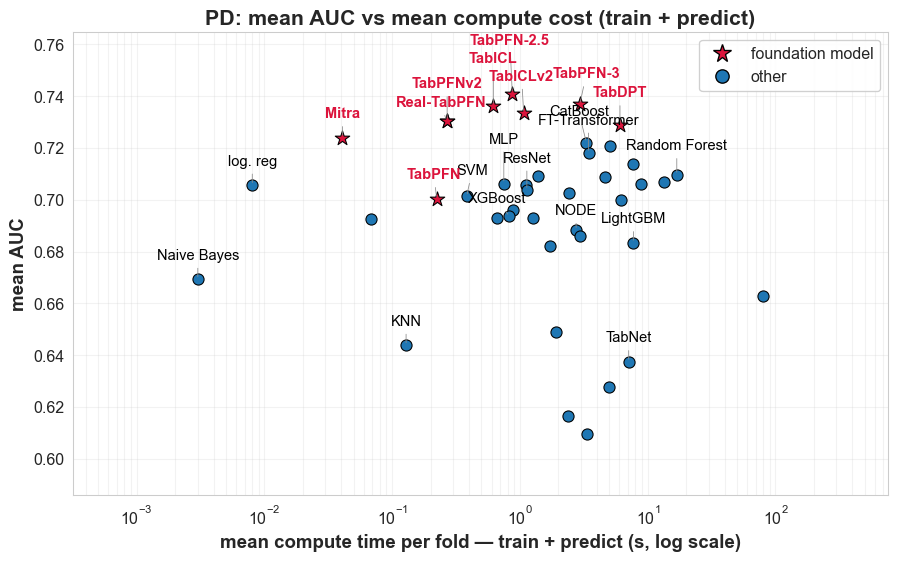

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment0/pd_cost_quality_auc.pdf')

In [5]:
compute_time_bars(df, task_name='PD', out_dir=FIGURES_DIR)
compute_time_boxplot(df, task_name='PD', out_dir=FIGURES_DIR)
runtime_performance_scatter(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)


## LGD — R²

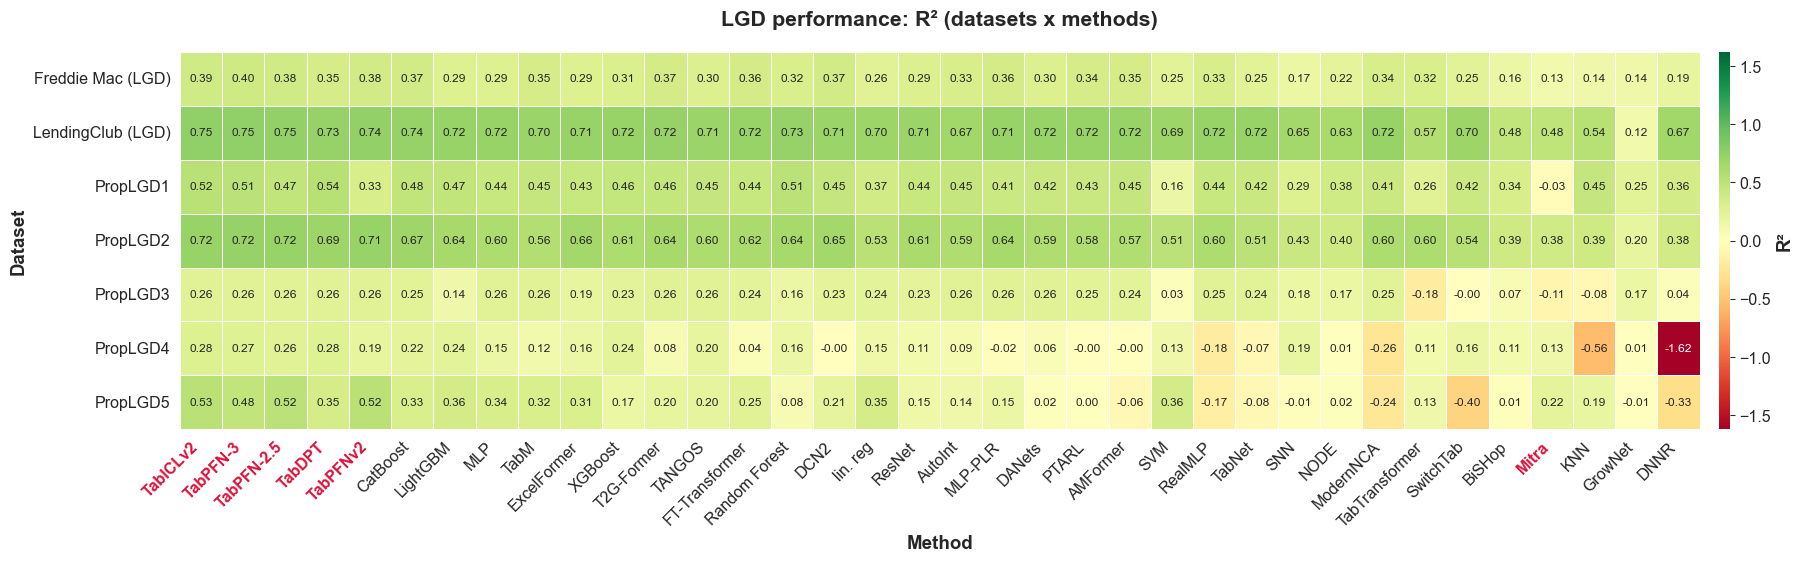

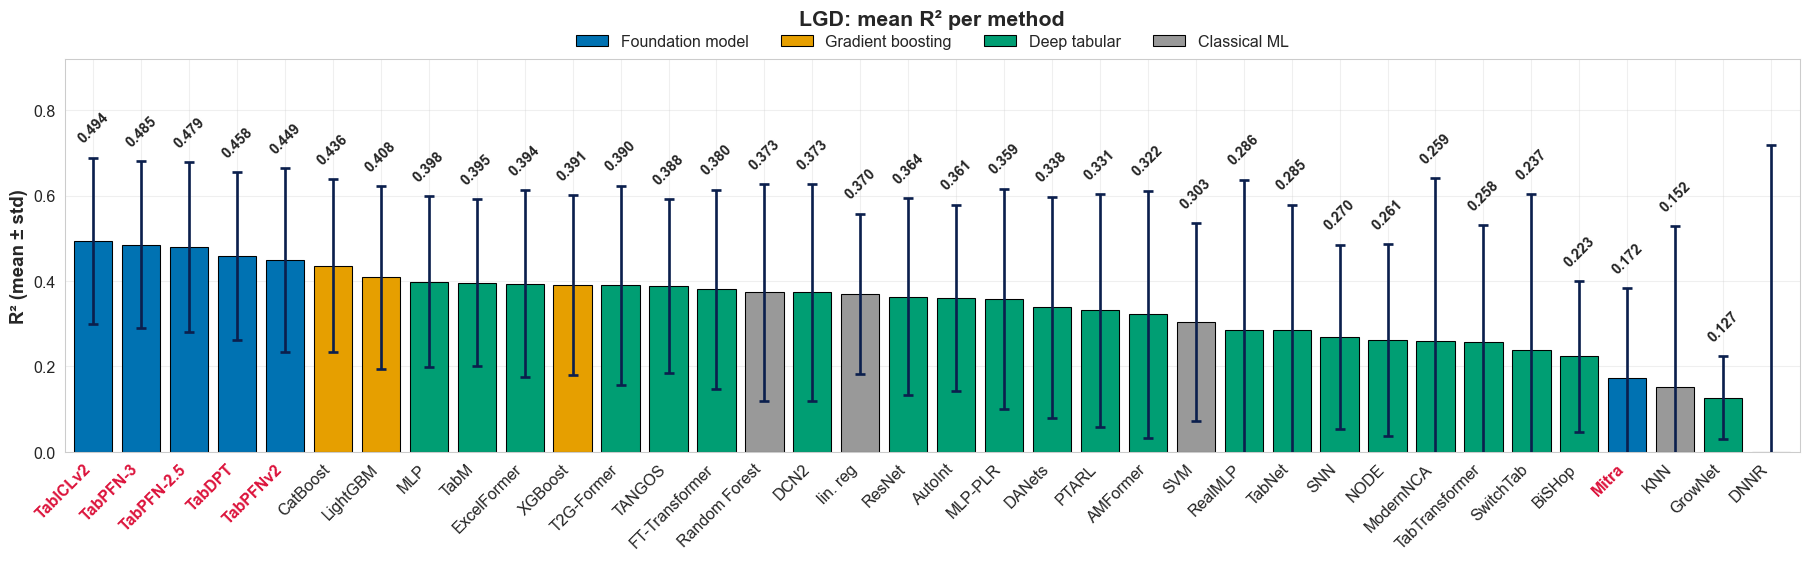

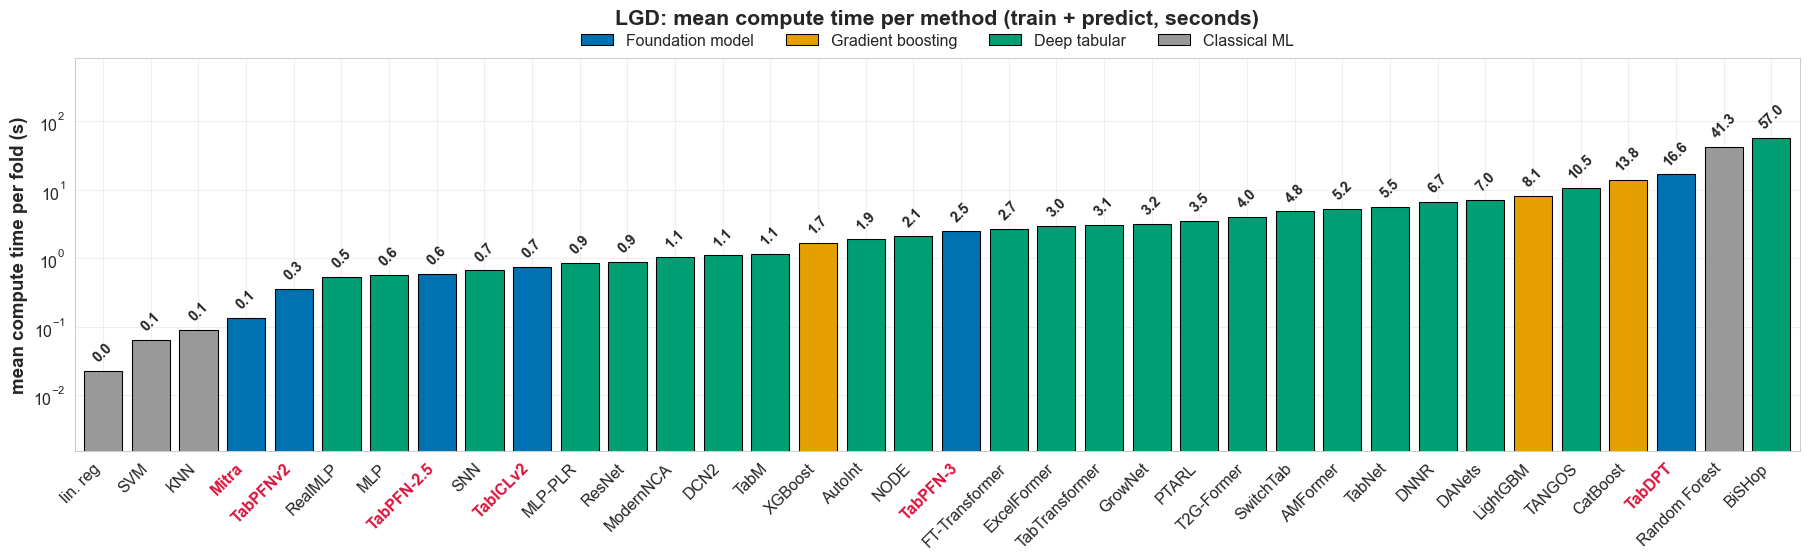

In [6]:
if df_lgd is not None:
    performance_heatmap(df_lgd, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
    metric_bars(df_lgd, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
    compute_time_bars(df_lgd, task_name='LGD', out_dir=FIGURES_DIR)


## Summary — the notebook's single printed report

Everything above, in text: this is the notebook's ONLY printed output, so `results/All_Results.md` is a complete text record of the analysis.

In [7]:
notebook_report(
    'Experiment 0 - pilot',
    notebook='Experiment0.ipynb',
    about=('Single-split pilot over every registered method on all PD and LGD '
           'datasets: which methods run end-to-end, and a first performance / '
           'cost overview. Used to curate the Experiment 1 method set.'),
    sections=[
        section('PD coverage',
                f'{df["method"].nunique()} methods x {df["dataset"].nunique()} datasets'),
        section('PD metrics per method + compute time',
                capture(pd_summary_text, df, task_name='Experiment 0 - PD (pilot)')),
        section('LGD coverage',
                (f'{df_lgd["method"].nunique()} methods x {df_lgd["dataset"].nunique()} datasets'
                 if df_lgd is not None else 'no LGD results available')),
        section('LGD metrics per method + compute time',
                (capture(lgd_summary_text, df_lgd, task_name='Experiment 0 - LGD (pilot)')
                 if df_lgd is not None else 'no LGD results available')),
    ],
)

EXPERIMENT 0 - PILOT -- COMPLETE TEXT SUMMARY
Source notebook : notebooks/Experiment0.ipynb
Contents        : Single-split pilot over every registered method on all PD and LGD datasets: which methods run end-to-end, and a first performance / cost overview. Used to curate the Experiment 1 method set.
Sections        : 4

This is the notebook's ONLY printed output: every table and figure-backing
number it produces is reproduced below, so results/All_Results.md is a
complete text record of the analysis.

------------------------------------------------------------------------------
[1] PD coverage
------------------------------------------------------------------------------
42 methods x 14 datasets

------------------------------------------------------------------------------
[2] PD metrics per method + compute time
------------------------------------------------------------------------------
Experiment 0 - PD (pilot) — mean of every metric per method   (datasets: 14, methods: 42)
    

"==============================================================================\nEXPERIMENT 0 - PILOT -- COMPLETE TEXT SUMMARY\n==============================================================================\nSource notebook : notebooks/Experiment0.ipynb\nContents        : Single-split pilot over every registered method on all PD and LGD datasets: which methods run end-to-end, and a first performance / cost overview. Used to curate the Experiment 1 method set.\nSections        : 4\n\nThis is the notebook's ONLY printed output: every table and figure-backing\nnumber it produces is reproduced below, so results/All_Results.md is a\ncomplete text record of the analysis.\n\n------------------------------------------------------------------------------\n[1] PD coverage\n------------------------------------------------------------------------------\n42 methods x 14 datasets\n\n------------------------------------------------------------------------------\n[2] PD metrics per method + compute ti